## Question
**Is the average number of fouls suffered per 90 minutes significantly different between forwards and midfielders in the FIFA World Cup 2026?**

This analysis compares forwards and midfielders using fouls suffered per 90 minutes. A per-90 measure is used because players had different amounts of playing time during the tournament, allowing a fairer comparison between the two groups.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
from pathlib import Path

# Support kernels launched from this topic folder or the repository root.
TOPIC = Path.cwd()
if not (TOPIC / "data" / "worldcup2026_misc.csv").is_file():
    TOPIC = TOPIC / "topics" / "03_fouls_suffered"
DATA = TOPIC / "data"
OUTPUTS = TOPIC / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA / "worldcup2026_misc.csv")

df.head()

,Rk,Player,Pos,Squad,Age,Born,90s,CrdY,CrdR,2CrdY,...,Fld,Off,Crs,Int,TklW,PKwon,PKcon,OG,Matches,-9999
0,1,Brenden Aaronson,MF,us USA,25,2000,0.8,0,0,0,...,1,0,1,0,1,NaN,NaN,0,Matches,5bc43860
1,2,Thelo Aasgaard,MF,no Norway,24,2002,1.0,0,0,0,...,3,0,0,3,1,NaN,NaN,0,Matches,c88a28b9
2,3,Hamza Abdelkarim,FW,eg Egypt,18,2008,0.7,0,0,0,...,0,0,0,0,0,NaN,NaN,0,Matches,057d8f12
3,4,Hossam Abdelmaguid,DF,eg Egypt,25,2001,0.7,0,0,0,...,0,0,0,1,0,NaN,NaN,0,Matches,accbfc94
4,5,Mohamed Abdelmonem,DF,eg Egypt,27,1999,0.2,0,0,0,...,0,0,0,0,0,NaN,NaN,0,Matches,bff15d74


### Check for Missing Values

The variables required for the analysis were checked for missing values before further cleaning. The main variables used were player position (`Pos`), playing time (`90s`) and fouls suffered (`Fld`).

In [24]:
df[["Pos", "90s", "Fld"]].isnull().sum()

Pos    0
90s    0
Fld    0
dtype: int64

No missing values were found in the variables required for the analysis, so no additional missing-value treatment was necessary.

## Data Wrangling

The player position variable was examined because some players had multiple listed positions. The first listed position was treated as the player's primary position. Players whose primary position began with `FW` were classified as forwards, while those beginning with `MF` were classified as midfielders.

In [3]:
# Check player position categories
df["Pos"].value_counts()

Pos
MF      344
DF      306
FW      159
FWMF     77
GK       62
DFMF     40
MFFW     36
MFDF     12
DFFW      3
Name: count, dtype: int64

In [4]:
# Select forwards and midfielders
forwards = df[df["Pos"].str.startswith("FW")]
midfielders = df[df["Pos"].str.startswith("MF")]

print("Forwards before cleaning:", len(forwards))
print("Midfielders before cleaning:", len(midfielders))

Forwards before cleaning: 236
Midfielders before cleaning: 392


Players with zero recorded playing time were removed because fouls suffered per 90 minutes cannot be calculated meaningfully when a player has no playing time.

In [5]:
# Remove players with zero playing time
forwards = forwards[forwards["90s"] > 0].copy()
midfielders = midfielders[midfielders["90s"] > 0].copy()

print("Eligible forwards:", len(forwards))
print("Eligible midfielders:", len(midfielders))

Eligible forwards: 223
Eligible midfielders: 385


### Calculate Fouls Suffered per 90 Minutes

The response variable was calculated by dividing fouls drawn/suffered (`Fld`) by the number of 90-minute periods played (`90s`). This standardises the foul count so players with different amounts of playing time can be compared fairly.

In [6]:
# Calculate fouls suffered per 90 minutes
forwards["Fouls_per_90"] = forwards["Fld"] / forwards["90s"]
midfielders["Fouls_per_90"] = midfielders["Fld"] / midfielders["90s"]

In [7]:
forwards[["Player", "Pos", "90s", "Fld", "Fouls_per_90"]].head()

,Player,Pos,90s,Fld,Fouls_per_90
2,Hamza Abdelkarim,FW,0.7,0,0.000000
8,Yusuf Abdurisag,FW,1.1,2,1.818182
15,Elias Achouri,FWMF,0.5,1,2.000000
16,Ché Adams,FW,1.6,2,1.250000
21,Simon Adingra,FWMF,0.2,0,0.000000


In [8]:
midfielders[["Player", "Pos", "90s", "Fld", "Fouls_per_90"]].head()

,Player,Pos,90s,Fld,Fouls_per_90
0,Brenden Aaronson,MF,0.8,1,1.250000
1,Thelo Aasgaard,MF,1.0,3,3.000000
17,Jayden Adams,MF,1.3,0,0.000000
18,Tyler Adams,MF,3.8,6,1.578947
23,Michel Aebischer,MFFW,1.7,2,1.176471


For example, a player who suffered 2 fouls while playing 1.6 units of 90 minutes would have:

\[
\frac{2}{1.6} = 1.25
\]

Therefore, that player suffered approximately 1.25 fouls per 90 minutes.

## Data Preparation and Sampling

The population consisted of all eligible forwards and midfielders who recorded playing time in the FIFA World Cup 2026 dataset.

A stratified random sample was used by selecting players separately from the forward and midfielder groups. A sample of 100 forwards and 100 midfielders was selected to provide a balanced comparison between the two positions.

A fixed random state of 42 was used so that the same sample can be reproduced each time the notebook is run.

In [9]:
# Randomly select 100 players from each position group
forward_sample = forwards.sample(n=100, random_state=42)
midfielder_sample = midfielders.sample(n=100, random_state=42)

print("Forward sample size:", len(forward_sample))
print("Midfielder sample size:", len(midfielder_sample))

Forward sample size: 100
Midfielder sample size: 100


In [10]:
forward_sample[["Player", "Pos", "90s", "Fld", "Fouls_per_90"]].head()

,Player,Pos,90s,Fld,Fouls_per_90
43,Mohanad Ali,FW,0.1,0,0.000000
373,Erling Haaland,FW,5.2,3,0.576923
516,Noa Lang,FWMF,0.1,1,10.000000
657,Iliman Ndiaye,FW,1.3,1,0.769231
1028,Alejandro Zendejas,FWMF,0.2,0,0.000000


In [11]:
midfielder_sample[["Player", "Pos", "90s", "Fld", "Fouls_per_90"]].head()

,Player,Pos,90s,Fld,Fouls_per_90
732,Kevin Pina,MF,3.9,3,0.769231
690,Michael Olise,MF,7.2,16,2.222222
970,Obed Vargas,MF,0.7,0,0.000000
904,Ivan Šunjić,MF,2.2,0,0.000000
143,Jordy Bos,MFDF,3.4,4,1.176471


## Descriptive Statistics

Descriptive statistics were calculated for the sampled forwards and midfielders to compare the centre and spread of fouls suffered per 90 minutes.

In [13]:
print("Descriptive Statistics - Forwards")
print(forward_sample["Fouls_per_90"].describe())

print("\nDescriptive Statistics - Midfielders")
print(midfielder_sample["Fouls_per_90"].describe())

Descriptive Statistics - Forwards
count    100.000000
mean       1.577500
std        2.035643
min        0.000000
25%        0.000000
50%        1.234756
75%        2.000000
max       10.000000
Name: Fouls_per_90, dtype: float64

Descriptive Statistics - Midfielders
count    100.000000
mean       1.218256
std        0.997557
min        0.000000
25%        0.370370
50%        1.111111
75%        1.818182
max        5.000000
Name: Fouls_per_90, dtype: float64


In [14]:
# Calculate IQR for forwards
forward_q1 = forward_sample["Fouls_per_90"].quantile(0.25)
forward_q3 = forward_sample["Fouls_per_90"].quantile(0.75)
forward_iqr = forward_q3 - forward_q1

# Calculate IQR for midfielders
midfield_q1 = midfielder_sample["Fouls_per_90"].quantile(0.25)
midfield_q3 = midfielder_sample["Fouls_per_90"].quantile(0.75)
midfield_iqr = midfield_q3 - midfield_q1

print("Forward IQR:", forward_iqr)
print("Midfielder IQR:", midfield_iqr)

Forward IQR: 2.0
Midfielder IQR: 1.4478114478114477


In [15]:
summary = pd.DataFrame({
    "Forwards": [
        len(forward_sample),
        forward_sample["Fouls_per_90"].mean(),
        forward_sample["Fouls_per_90"].median(),
        forward_sample["Fouls_per_90"].std(),
        forward_q1,
        forward_q3,
        forward_iqr,
        forward_sample["Fouls_per_90"].min(),
        forward_sample["Fouls_per_90"].max()
    ],
    
    "Midfielders": [
        len(midfielder_sample),
        midfielder_sample["Fouls_per_90"].mean(),
        midfielder_sample["Fouls_per_90"].median(),
        midfielder_sample["Fouls_per_90"].std(),
        midfield_q1,
        midfield_q3,
        midfield_iqr,
        midfielder_sample["Fouls_per_90"].min(),
        midfielder_sample["Fouls_per_90"].max()
    ]
}, index=[
    "Sample Size",
    "Mean",
    "Median",
    "Standard Deviation",
    "Q1",
    "Q3",
    "IQR",
    "Minimum",
    "Maximum"
])

summary.round(3)

,Forwards,Midfielders
Sample Size,100.000,100.000
Mean,1.577,1.218
Median,1.235,1.111
Standard Deviation,2.036,0.998
Q1,0.000,0.370
Q3,2.000,1.818
IQR,2.000,1.448
Minimum,0.000,0.000
Maximum,10.000,5.000


## Boxplot and Outlier Analysis

A boxplot was created to compare the distribution of fouls suffered per 90 minutes between forwards and midfielders. The plot helps compare the median, spread, interquartile range and potential outliers in the two groups.

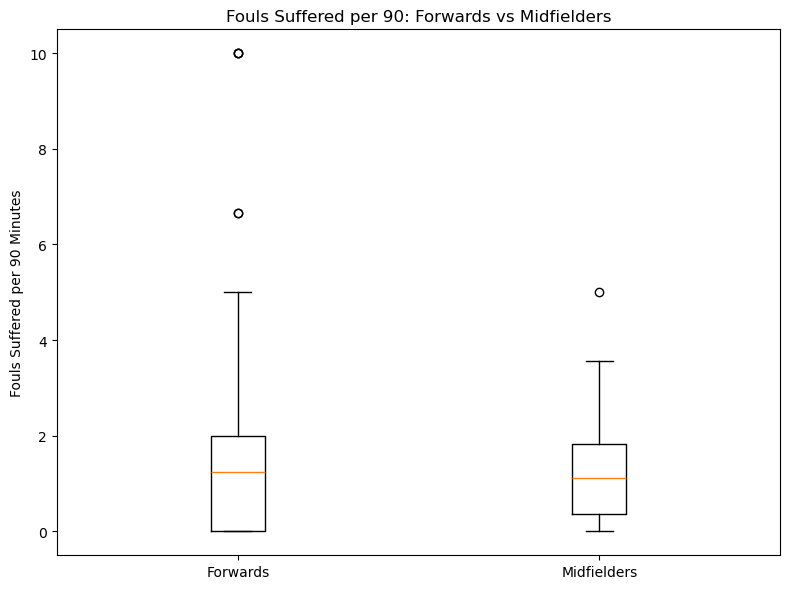

In [17]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    [
        forward_sample["Fouls_per_90"],
        midfielder_sample["Fouls_per_90"]
    ],
    tick_labels=["Forwards", "Midfielders"]
)

plt.title("Fouls Suffered per 90: Forwards vs Midfielders")
plt.ylabel("Fouls Suffered per 90 Minutes")

plt.tight_layout()
plt.savefig(OUTPUTS / "figure_01.png", dpi=200, bbox_inches="tight")
plt.show()

### Interpretation

The boxplot shows considerable overlap between the two groups. However, the forward sample has a wider spread than the midfielder sample, indicating greater variability in fouls suffered per 90 minutes.

The forward group also contains two relatively high outliers, while the midfielder group contains one high outlier. These observations were retained because there was no evidence that they were data-entry errors. Some high per-90 values may occur when players have relatively low playing time.

## 95% Confidence Interval

A 95% confidence interval was calculated for the difference in mean fouls suffered per 90 minutes between forwards and midfielders.

In [18]:
forward_values = forward_sample["Fouls_per_90"]
midfield_values = midfielder_sample["Fouls_per_90"]

# Difference between sample means
mean_difference = forward_values.mean() - midfield_values.mean()

# Sample sizes
n1 = len(forward_values)
n2 = len(midfield_values)

# Standard deviations
s1 = forward_values.std()
s2 = midfield_values.std()

# Standard error
se = np.sqrt((s1**2 / n1) + (s2**2 / n2))

# Welch degrees of freedom
df_welch = ((s1**2 / n1) + (s2**2 / n2))**2 / (
    ((s1**2 / n1)**2 / (n1 - 1)) +
    ((s2**2 / n2)**2 / (n2 - 1))
)

# Critical t-value
t_critical = stats.t.ppf(0.975, df_welch)

# Confidence interval
ci_lower = mean_difference - t_critical * se
ci_upper = mean_difference + t_critical * se

print("Mean difference:", round(mean_difference, 3))
print("95% Confidence Interval:",
      round(ci_lower, 3), "to", round(ci_upper, 3))

Mean difference: 0.359
95% Confidence Interval: -0.089 to 0.807


### Interpretation

The estimated mean difference was approximately 0.359 fouls suffered per 90 minutes, with forwards having the higher sample mean.

The 95% confidence interval ranged from approximately -0.089 to 0.807. Since the interval includes zero, a true difference of zero between forwards and midfielders remains plausible.

## Welch Two-Sample t-Test

A Welch independent two-sample t-test was used to determine whether the mean number of fouls suffered per 90 minutes differed significantly between forwards and midfielders.

**Null hypothesis (H₀):** The two population means are equal.

**Alternative hypothesis (H₁):** The two population means are different.

A significance level of 0.05 was used.

In [26]:
# Welch's independent two-sample t-test
t_stat, p_value = stats.ttest_ind(
    forward_values,
    midfield_values,
    equal_var=False
)

print("Welch's Two-Sample t-Test")
print("--------------------------")
print("Forward mean:", round(forward_values.mean(), 3))
print("Midfielder mean:", round(midfield_values.mean(), 3))
print("Mean difference:", round(mean_difference, 3))
print("T-statistic:", round(t_stat, 3))
print("P-value:", round(p_value, 3))
print("95% CI:", round(ci_lower, 3), "to", round(ci_upper, 3))

Welch's Two-Sample t-Test
--------------------------
Forward mean: 1.577
Midfielder mean: 1.218
Mean difference: 0.359
T-statistic: 1.585
P-value: 0.115
95% CI: -0.089 to 0.807


### Interpretation

The test produced a t-statistic of approximately 1.585 and a p-value of 0.115.

Since the p-value is greater than 0.05, the null hypothesis is not rejected. Therefore, there is insufficient statistical evidence to conclude that the average number of fouls suffered per 90 minutes differs significantly between forwards and midfielders.

## Conclusion

The forward sample recorded a mean of approximately 1.578 fouls suffered per 90 minutes, compared with 1.218 for midfielders.

Although forwards had a higher observed average, Welch's two-sample t-test produced a p-value of 0.115, which is greater than the 0.05 significance level. The 95% confidence interval for the mean difference was approximately (-0.089, 0.807), which also included zero.

Therefore, there is insufficient evidence to conclude that the average number of fouls suffered per 90 minutes was significantly different between forwards and midfielders in the FIFA World Cup 2026.

## Limitations

One limitation of the analysis is that some players recorded relatively little playing time. A player who suffers one or two fouls in only a small number of minutes can have a very high per-90 rate, which may contribute to the outliers observed in the boxplot.

In addition, players with multiple listed positions were classified according to their first listed position. This provides a consistent classification rule, but it may not fully represent players who regularly perform more than one positional role.

The analysis is also based on a random sample of 100 players from each position group rather than all eligible players, so the statistical results are subject to sampling variability.